# 34 - LSEG/Gemma matched-count FinBERT scorer substitution

**Question.** On the robust original-33 universe, does Gemma select more
useful companies and sectors than a generous FinBERT rank substitute when
activity, long/short counts, capacity, horizon, and accounting are fixed?

This is an **opened-window scorer-mechanism audit**, not a policy search or
independent validation. Notebook 33's 70 capped Gemma event sessions and
exact per-session +1/-1 name counts are immutable. The Gemma arm is reproduced
exactly. On those same sessions, the FinBERT substitute selects the highest
`n_positive` and lowest `n_negative` firms by its continuous strongest-event
score, receives the same capacity-constrained leg budget, and otherwise holds
cash. This deliberately gives FinBERT a rank-based route around the fact that
it has no exact +/-1 strongest-event values. It is a diagnostic comparator,
not a deployable FinBERT strategy.

The frozen family contains the capped stock book and the unchanged equal-
weight sector projection. For each, a **scorer-selection gate** requires a
positive Gemma-minus-FinBERT net-return interval after BH across the two rules
and positive paired mean in both chronological halves. Costs are 10 bps per
traded side, with 4,999 five-session circular-block replications. No threshold,
count, cap, leverage, holding period, or cost is selected from returns.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
    sector_project_targets,
)
from sentiment_benchmark.strategy_research.ledger import run_open_to_open_ledger  # noqa: E402
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    PositionTarget,
    TargetPortfolio,
)

SEED = 20260809
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
REPLICATIONS = 4_999
SINGLE_NAME_CAP = 0.25
INITIAL_NAV = 1_000_000.0
SCORERS = ("gemma4_26b", "finbert_rank_substitute")
RULES = ("capacity_capped", "between_sector")

AGGREGATE_DIR = REPO_ROOT / "final_experiments/outputs/13_lseg_44_gemma_robustness"
GEMMA_PATH = AGGREGATE_DIR / "gemma4_26b_firm_open_aggregators.parquet"
FINBERT_PATH = AGGREGATE_DIR / "finbert_firm_open_aggregators.parquet"
NOTEBOOK33_MANIFEST = (
    REPO_ROOT
    / "final_experiments/outputs/33_lseg_gemma_original33_universe_robustness/manifest.json"
)
PRICE_PATH = REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv"
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/34_lseg_gemma_finbert_matched_count_substitution"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Frozen original-33 panel and return reproduction

Only aggregate scorer outputs and prices are loaded. No licensed headline text
is read or persisted.

In [2]:
original_sector_members = {
    sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()
}
original_symbols = tuple(
    symbol for members in original_sector_members.values() for symbol in members
)
sector_by_symbol = {
    symbol: sector
    for sector, members in original_sector_members.items()
    for symbol in members
}
gemma = pd.read_parquet(GEMMA_PATH)
finbert = pd.read_parquet(FINBERT_PATH)
for frame in (gemma, finbert):
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()
gemma = gemma.loc[gemma["symbol"].isin(original_symbols)].copy()
finbert = finbert.loc[finbert["symbol"].isin(original_symbols)].copy()
if gemma.duplicated(["session_date", "symbol"]).any() or finbert.duplicated(
    ["session_date", "symbol"]
).any():
    raise ValueError("duplicate scorer firm-open rows")
if not gemma[["session_date", "symbol"]].equals(
    finbert[["session_date", "symbol"]]
):
    raise ValueError("paired scorer panels are not row-aligned")

prices = pd.read_csv(PRICE_PATH, parse_dates=["session_date"])
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
if prices.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate price rows")
open_wide = prices.pivot(index="session_date", columns="symbol", values="open").sort_index().dropna()
sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
symbols = tuple(sorted(gemma["symbol"].unique()))
if set(symbols) != set(original_symbols) or set(open_wide.columns) != set(original_symbols):
    raise ValueError("expected immutable original-33 population")
if not gemma.groupby("session_date")["symbol"].nunique().eq(33).all():
    raise ValueError("Gemma panel is not complete by session")
if not finbert.groupby("session_date")["symbol"].nunique().eq(33).all():
    raise ValueError("FinBERT panel is not complete by session")
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("signal sessions are not consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide):
    raise ValueError("last signal session lacks a next open")

return_rows: list[OpenToOpenReturn] = []
recomputed: list[dict[str, object]] = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    values = open_wide.loc[next_session, list(symbols)] / open_wide.loc[session, list(symbols)] - 1.0
    for symbol, value in values.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed.append(
            {"session_date": session, "symbol": symbol, "recomputed": float(value)}
        )
return_audit = gemma[["session_date", "symbol", "raw_open_h1"]].merge(
    pd.DataFrame(recomputed), on=["session_date", "symbol"], validate="1:1"
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("recomputed returns do not reproduce aggregate panel")
coverage = pd.DataFrame(
    [
        {
            "sessions": len(sessions),
            "companies": len(symbols),
            "sectors": len(original_sector_members),
            "paired_scorer_rows": len(gemma),
            "first_session": sessions.min(),
            "last_session": sessions.max(),
            "max_return_reproduction_error": float(return_audit["absolute_error"].max()),
        }
    ]
)
display(coverage)

,sessions,companies,sectors,paired_scorer_rows,first_session,last_session,max_return_reproduction_error
0,167,33,11,5511,2025-10-27,2026-06-26,0.000000


## Matched-count return-blind target construction

The substitute uses FinBERT only to rank names. Gemma determines the dates,
exact long/short counts, and therefore the capacity-constrained gross budget.

In [3]:
gemma_capped, gemma_audit = build_exact_extrema_targets(
    gemma, single_name_cap=SINGLE_NAME_CAP
)


def build_rank_substitution_targets(
    panel: pd.DataFrame,
    reference_audit: pd.DataFrame,
) -> tuple[tuple[TargetPortfolio, ...], pd.DataFrame]:
    required = {"session_date", "symbol", "strongest_event"}
    if missing := required - set(panel.columns):
        raise ValueError(f"rank panel missing {sorted(missing)}")
    frame = panel.loc[:, list(required)].copy()
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()
    if frame.duplicated(["session_date", "symbol"]).any():
        raise ValueError("rank panel contains duplicate rows")
    if frame["strongest_event"].isna().any():
        raise ValueError("rank substitute requires complete scores")
    audit = reference_audit.set_index("session_date")
    rank_sessions = pd.DatetimeIndex(reference_audit["session_date"])
    target_rows: list[TargetPortfolio] = []
    audit_rows: list[dict[str, object]] = []
    for session in rank_sessions:
        day = frame.loc[frame["session_date"].eq(session)].sort_values(
            ["strongest_event", "symbol"],
            ascending=[False, True],
            kind="mergesort",
        )
        if len(day) != len(symbols):
            raise ValueError("rank panel session is incomplete")
        reference = audit.loc[session]
        n_positive = int(reference["positive_names"])
        n_negative = int(reference["negative_names"])
        eligible = bool(reference["eligible"])
        long_symbols: set[str] = set()
        short_symbols: set[str] = set()
        leg_exposure = 0.0
        if eligible:
            long_symbols = set(day.head(n_positive)["symbol"])
            short_symbols = set(day.tail(n_negative)["symbol"])
            if long_symbols & short_symbols:
                raise RuntimeError("ranked long and short selections overlap")
            leg_exposure = min(
                0.5,
                SINGLE_NAME_CAP * n_positive,
                SINGLE_NAME_CAP * n_negative,
            )
        weight_by_symbol = {symbol: 0.0 for symbol in symbols}
        if eligible:
            for symbol in long_symbols:
                weight_by_symbol[symbol] = leg_exposure / n_positive
            for symbol in short_symbols:
                weight_by_symbol[symbol] = -leg_exposure / n_negative
        positions = tuple(
            PositionTarget(
                symbol=symbol,
                action=1.0 if symbol in long_symbols else -1.0 if symbol in short_symbols else 0.0,
                volatility=None,
                raw_weight=weight_by_symbol[symbol],
                target_weight=weight_by_symbol[symbol],
                exclusion_reason=None,
            )
            for symbol in symbols
        )
        weights = np.array([weight_by_symbol[symbol] for symbol in symbols])
        gross = float(np.abs(weights).sum())
        target_rows.append(
            TargetPortfolio(
                session=str(session.date()),
                positions=positions,
                gross_exposure=gross,
                net_exposure=float(weights.sum()),
                long_exposure=float(weights[weights > 0].sum()),
                short_exposure=float(-weights[weights < 0].sum()),
                cash_weight=1.0 - float(weights.sum()),
            )
        )
        audit_rows.append(
            {
                "session_date": session,
                "eligible": eligible,
                "positive_names": n_positive,
                "negative_names": n_negative,
                "selected_long_names": len(long_symbols),
                "selected_short_names": len(short_symbols),
                "gross_exposure": gross,
                "leg_exposure": leg_exposure,
                "max_abs_name_weight": float(np.abs(weights).max()),
            }
        )
    return tuple(target_rows), pd.DataFrame(audit_rows)


finbert_capped, finbert_audit = build_rank_substitution_targets(finbert, gemma_audit)
for column in ("eligible", "positive_names", "negative_names", "gross_exposure", "leg_exposure"):
    if not np.allclose(
        gemma_audit[column].astype(float), finbert_audit[column].astype(float), atol=1e-12
    ):
        raise RuntimeError(f"matched construction failed for {column}")

gemma_projected, gemma_projected_audit = sector_project_targets(
    gemma_capped,
    sector_by_symbol=sector_by_symbol,
    single_name_cap=SINGLE_NAME_CAP,
)
finbert_projected, finbert_projected_audit = sector_project_targets(
    finbert_capped,
    sector_by_symbol=sector_by_symbol,
    single_name_cap=SINGLE_NAME_CAP,
)


def weight_matrix(targets: tuple[TargetPortfolio, ...]) -> np.ndarray:
    return np.vstack(
        [np.array([target.weights()[symbol] for symbol in symbols]) for target in targets]
    )


gemma_weights = weight_matrix(gemma_capped)
finbert_weights = weight_matrix(finbert_capped)
active = gemma_audit["eligible"].to_numpy(dtype=bool)
long_overlap = []
short_overlap = []
for row in np.flatnonzero(active):
    gemma_long = set(np.flatnonzero(gemma_weights[row] > 0))
    finbert_long = set(np.flatnonzero(finbert_weights[row] > 0))
    gemma_short = set(np.flatnonzero(gemma_weights[row] < 0))
    finbert_short = set(np.flatnonzero(finbert_weights[row] < 0))
    long_overlap.append(len(gemma_long & finbert_long) / len(gemma_long))
    short_overlap.append(len(gemma_short & finbert_short) / len(gemma_short))

finbert_exact_extrema = pd.DataFrame(
    [
        {
            "finbert_exact_positive_values": int(finbert["strongest_event"].eq(1.0).sum()),
            "finbert_exact_negative_values": int(finbert["strongest_event"].eq(-1.0).sum()),
            "gemma_active_sessions": int(active.sum()),
            "finbert_sessions_with_both_score_signs_on_gemma_active_dates": int(
                finbert.loc[finbert["session_date"].isin(gemma_audit.loc[active, "session_date"])]
                .groupby("session_date")["strongest_event"]
                .agg(lambda values: bool((values > 0).any() and (values < 0).any()))
                .sum()
            ),
            "mean_long_selection_overlap": float(np.mean(long_overlap)),
            "mean_short_selection_overlap": float(np.mean(short_overlap)),
            "construction_exactly_count_and_exposure_matched": True,
        }
    ]
)
display(finbert_exact_extrema.T)

,0
finbert_exact_positive_values,0
finbert_exact_negative_values,0
gemma_active_sessions,70
finbert_sessions_with_both_score_signs_on_gemma_active_dates,38
mean_long_selection_overlap,0.032619
mean_short_selection_overlap,0.095238
construction_exactly_count_and_exposure_matched,True


## Drift-aware paths, costs, and paired inference

In [4]:
def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one terminal liquidation")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"]) - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    return intervals


def run_targets(
    targets: tuple[TargetPortfolio, ...],
    returns: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    full = ledger_rows_to_frame(
        run_open_to_open_ledger(
            targets,
            returns,
            cost_rate_per_side=cost_bps / 10_000.0,
            initial_nav_usd=INITIAL_NAV,
            force_final_liquidation=True,
        )
    )
    return fold_final_liquidation(full), full


def summarize(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, equity]
    turnover = float(daily["turnover"].sum())
    return {
        "n_sessions": len(daily),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(gross.mean()),
        "mean_net": float(net.mean()),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "total_return_gross": float(np.prod(1.0 + gross) - 1.0),
        "total_return_net": float(equity[-1] - 1.0),
        "max_drawdown": float(np.min(with_start / np.maximum.accumulate(with_start) - 1.0)),
        "mean_turnover": float(turnover / len(daily)),
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover),
        "cost_bps_per_side": cost_bps,
    }


targets = {
    ("gemma4_26b", "capacity_capped"): gemma_capped,
    ("gemma4_26b", "between_sector"): gemma_projected,
    ("finbert_rank_substitute", "capacity_capped"): finbert_capped,
    ("finbert_rank_substitute", "between_sector"): finbert_projected,
}
daily_paths: dict[tuple[str, str], pd.DataFrame] = {}
ledger_paths: dict[tuple[str, str], pd.DataFrame] = {}
for key, target_rows in targets.items():
    daily_paths[key], ledger_paths[key] = run_targets(
        target_rows, return_rows, cost_bps=COST_BPS
    )
results = pd.DataFrame(
    [
        {"scorer": scorer, "rule": rule, **summarize(daily_paths[(scorer, rule)], cost_bps=COST_BPS)}
        for scorer in SCORERS
        for rule in RULES
    ]
)

notebook33 = json.loads(NOTEBOOK33_MANIFEST.read_text())
reference33 = pd.DataFrame(notebook33["results"]).set_index("arm")
for rule in RULES:
    observed = results.set_index(["scorer", "rule"]).loc[("gemma4_26b", rule)]
    for metric in ("mean_gross", "mean_net", "sharpe_gross", "sharpe_net", "total_return_net"):
        if not np.isclose(observed[metric], reference33.loc[rule, metric], atol=1e-10):
            raise RuntimeError(f"Notebook 33 reproduction failed for {rule}/{metric}")

paired_rows = []
for rule_number, rule in enumerate(RULES):
    paired_rows.append(
        {
            "rule": rule,
            "comparison": "gemma_minus_finbert_rank_substitute",
            **paired_block_bootstrap_difference(
                daily_paths[("gemma4_26b", rule)],
                daily_paths[("finbert_rank_substitute", rule)],
                value_col="net_return",
                block_length=BLOCK_LENGTH,
                replications=REPLICATIONS,
                seed=SEED + rule_number,
            ),
        }
    )
paired_inference = pd.DataFrame(paired_rows)
paired_inference["bh_reject_q05"] = benjamini_hochberg(
    paired_inference["p_two_sided"].tolist(), q=0.05
)

cost_rows = []
for cost in COST_GRID:
    for key, target_rows in targets.items():
        daily, _ = run_targets(target_rows, return_rows, cost_bps=cost)
        cost_rows.append(
            {"scorer": key[0], "rule": key[1], **summarize(daily, cost_bps=cost)}
        )
cost_curve = pd.DataFrame(cost_rows)
display(results)
display(paired_inference)

,scorer,rule,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,breakeven_bps_per_side,cost_bps_per_side
0,gemma4_26b,capacity_capped,167,70,0.000998,0.000605,3.343571,2.046340,0.179155,0.104240,-0.034238,0.393587,25.367665,10.000000
1,gemma4_26b,between_sector,167,68,0.000824,0.000470,4.182970,2.421115,0.146520,0.080701,-0.026617,0.354390,23.249248,10.000000
2,finbert_rank_substitute,capacity_capped,167,70,0.001127,0.000680,3.699940,2.271209,0.204584,0.118176,-0.029025,0.446484,25.235033,10.000000
3,finbert_rank_substitute,between_sector,167,68,0.000703,0.000321,3.506912,1.629533,0.123605,0.054256,-0.017270,0.381829,18.414185,10.000000


,rule,comparison,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,bh_reject_q05
0,capacity_capped,gemma_minus_finbert_rank_substitute,167,-0.000075,-0.000928,0.000727,0.866600,5,4999,20260809,False
1,between_sector,gemma_minus_finbert_rank_substitute,167,0.000148,-0.000416,0.000715,0.617800,5,4999,20260810,False


## Chronological stability and frozen gates

In [5]:
midpoint = len(sessions) // 2
half_indices = {"first_half": sessions[:midpoint], "second_half": sessions[midpoint:]}
temporal_rows = []
for period, index in half_indices.items():
    keep = {str(session.date()) for session in index}
    half_returns = [row for row in return_rows if row.session in keep]
    mask = gemma["session_date"].isin(index)
    half_gemma = gemma.loc[mask].copy()
    half_finbert = finbert.loc[mask].copy()
    half_gemma_capped, half_audit = build_exact_extrema_targets(
        half_gemma, single_name_cap=SINGLE_NAME_CAP
    )
    half_finbert_capped, _ = build_rank_substitution_targets(
        half_finbert, half_audit
    )
    half_targets = {
        ("gemma4_26b", "capacity_capped"): half_gemma_capped,
        ("finbert_rank_substitute", "capacity_capped"): half_finbert_capped,
        ("gemma4_26b", "between_sector"): sector_project_targets(
            half_gemma_capped,
            sector_by_symbol=sector_by_symbol,
            single_name_cap=SINGLE_NAME_CAP,
        )[0],
        ("finbert_rank_substitute", "between_sector"): sector_project_targets(
            half_finbert_capped,
            sector_by_symbol=sector_by_symbol,
            single_name_cap=SINGLE_NAME_CAP,
        )[0],
    }
    for key, target_rows in half_targets.items():
        daily, _ = run_targets(target_rows, half_returns, cost_bps=COST_BPS)
        temporal_rows.append(
            {"period": period, "scorer": key[0], "rule": key[1], **summarize(daily, cost_bps=COST_BPS)}
        )
temporal = pd.DataFrame(temporal_rows)

temporal_index = temporal.set_index(["period", "scorer", "rule"])
paired_index = paired_inference.set_index("rule")
gate_rows = []
for rule in RULES:
    half_differences = {
        period: float(
            temporal_index.loc[(period, "gemma4_26b", rule), "mean_net"]
            - temporal_index.loc[(period, "finbert_rank_substitute", rule), "mean_net"]
        )
        for period in half_indices
    }
    paired = paired_index.loc[rule]
    gate_rows.append(
        {
            "rule": rule,
            "scorer_selection_gate": bool(
                paired["ci_low"] > 0
                and paired["bh_reject_q05"]
                and all(value > 0 for value in half_differences.values())
            ),
            "gemma_minus_finbert_bps_session": float(paired["mean_difference"] * 10_000),
            "ci_low_bps_session": float(paired["ci_low"] * 10_000),
            "ci_high_bps_session": float(paired["ci_high"] * 10_000),
            "p_two_sided": float(paired["p_two_sided"]),
            "bh_reject_q05": bool(paired["bh_reject_q05"]),
            "first_half_difference_bps_session": half_differences["first_half"] * 10_000,
            "second_half_difference_bps_session": half_differences["second_half"] * 10_000,
        }
    )
gates = pd.DataFrame(gate_rows)
display(temporal)
display(gates)

,period,scorer,rule,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,breakeven_bps_per_side,cost_bps_per_side
0,first_half,gemma4_26b,capacity_capped,83,21,0.000479,0.000192,1.601496,0.648584,0.039591,0.015145,-0.034238,0.287003,16.691461,10.000000
1,first_half,finbert_rank_substitute,capacity_capped,83,21,0.001374,0.001107,4.078356,3.363973,0.119383,0.094927,-0.010908,0.267106,51.426349,10.000000
2,first_half,gemma4_26b,between_sector,83,19,0.000347,0.000094,1.986695,0.542854,0.028908,0.007513,-0.026617,0.253305,13.707300,10.000000
3,first_half,finbert_rank_substitute,between_sector,83,20,0.000661,0.000428,3.339700,2.221522,0.055966,0.035784,-0.009652,0.232862,28.392358,10.000000
4,second_half,gemma4_26b,capacity_capped,84,49,0.001512,0.001013,5.101135,3.438116,0.134249,0.087765,-0.014005,0.498902,30.299393,10.000000
5,second_half,finbert_rank_substitute,capacity_capped,84,49,0.000883,0.000259,3.269116,0.971511,0.076114,0.021234,-0.029025,0.623727,14.152369,10.000000
6,second_half,gemma4_26b,between_sector,84,49,0.001295,0.000841,6.062455,3.983331,0.114307,0.072643,-0.010161,0.454272,28.506568,10.000000
7,second_half,finbert_rank_substitute,between_sector,84,48,0.000745,0.000216,3.647840,1.065356,0.064054,0.017834,-0.017270,0.529023,14.074349,10.000000


,rule,scorer_selection_gate,gemma_minus_finbert_bps_session,ci_low_bps_session,ci_high_bps_session,p_two_sided,bh_reject_q05,first_half_difference_bps_session,second_half_difference_bps_session
0,capacity_capped,False,-0.753694,-9.277428,7.271436,0.866600,False,-9.144740,7.537459
1,between_sector,False,1.482628,-4.160033,7.153297,0.617800,False,-3.343793,6.251592


## Figures

findfont: Failed to find font weight medium, now using 400.


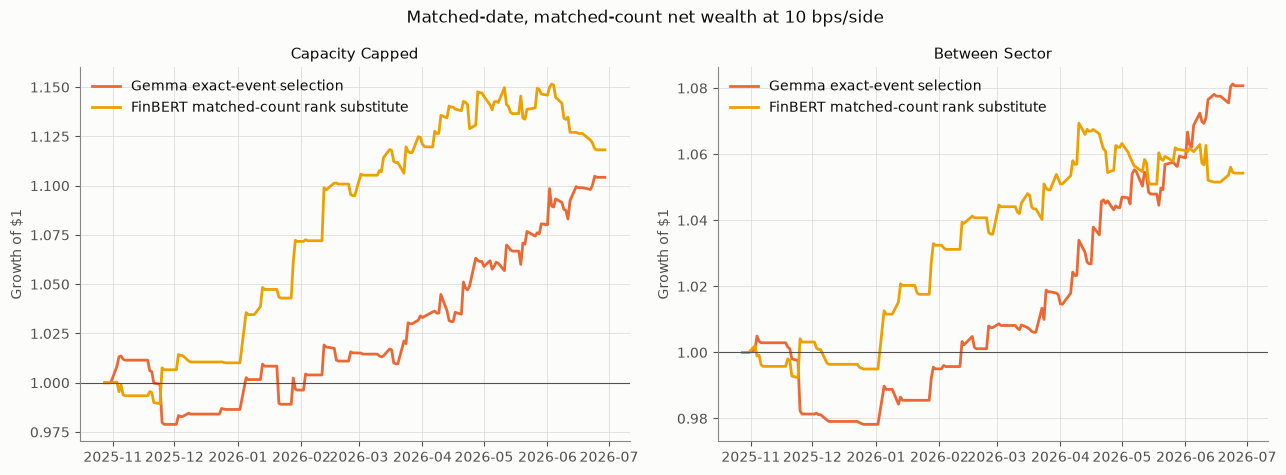

In [6]:
labels = {
    "gemma4_26b": "Gemma exact-event selection",
    "finbert_rank_substitute": "FinBERT matched-count rank substitute",
}
colours = {"gemma4_26b": CATEGORICAL[1], "finbert_rank_substitute": CATEGORICAL[3]}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for axis, rule in zip(axes, RULES, strict=True):
    for scorer in SCORERS:
        daily = daily_paths[(scorer, rule)]
        axis.plot(
            daily["return_end_date"],
            (1.0 + daily["net_return"]).cumprod(),
            color=colours[scorer],
            label=labels[scorer],
        )
    axis.axhline(1.0, color=INK["reference"], linewidth=0.8)
    axis.set_ylabel("Growth of $1")
    axis.set_title(rule.replace("_", " ").title())
    axis.legend(loc="best")
fig.suptitle("Matched-date, matched-count net wealth at 10 bps/side")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "matched_scorer_equity.png", dpi=170, bbox_inches="tight")
plt.show()

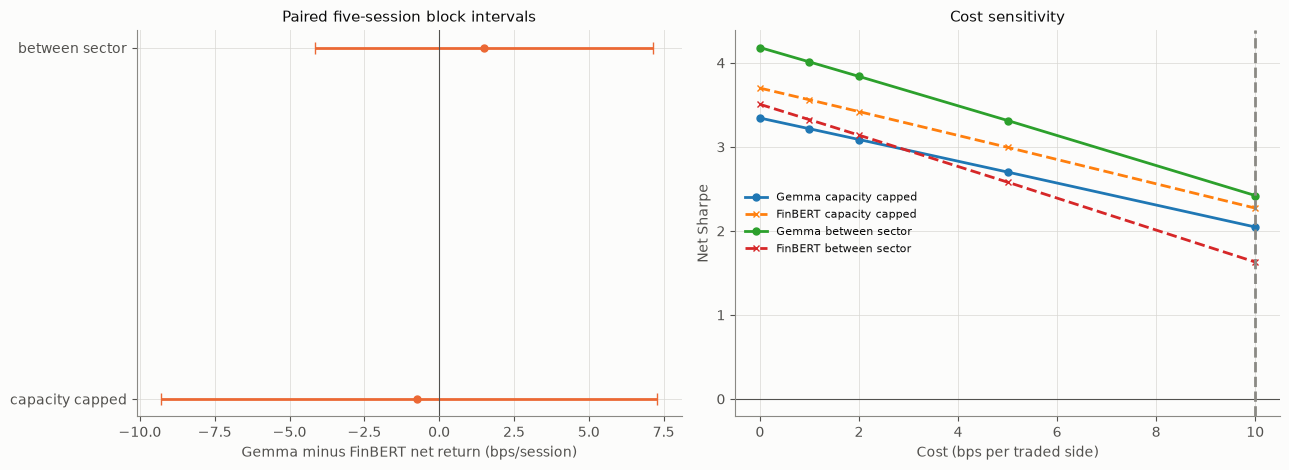

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
effect = paired_inference.set_index("rule").loc[list(RULES)]
y = np.arange(len(effect))
axes[0].errorbar(
    effect["mean_difference"] * 10_000,
    y,
    xerr=np.vstack(
        [
            (effect["mean_difference"] - effect["ci_low"]) * 10_000,
            (effect["ci_high"] - effect["mean_difference"]) * 10_000,
        ]
    ),
    fmt="o",
    color=colours["gemma4_26b"],
    capsize=4,
)
axes[0].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_yticks(y, [rule.replace("_", " ") for rule in effect.index])
axes[0].set_xlabel("Gemma minus FinBERT net return (bps/session)")
axes[0].set_title("Paired five-session block intervals")
for rule in RULES:
    line = cost_curve.loc[cost_curve["rule"].eq(rule) & cost_curve["scorer"].eq("gemma4_26b")]
    axes[1].plot(
        line["cost_bps_per_side"],
        line["sharpe_net"],
        marker="o",
        label=f"Gemma {rule.replace('_', ' ')}",
    )
    line = cost_curve.loc[
        cost_curve["rule"].eq(rule)
        & cost_curve["scorer"].eq("finbert_rank_substitute")
    ]
    axes[1].plot(
        line["cost_bps_per_side"],
        line["sharpe_net"],
        marker="x",
        linestyle="--",
        label=f"FinBERT {rule.replace('_', ' ')}",
    )
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].axvline(COST_BPS, color=INK["muted"], linestyle="--")
axes[1].set_xlabel("Cost (bps per traded side)")
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Cost sensitivity")
axes[1].legend(loc="best", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "paired_effects_and_costs.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate outputs and decision

In [8]:
coverage.to_csv(OUTPUT_DIR / "coverage.csv", index=False)
finbert_exact_extrema.to_csv(OUTPUT_DIR / "scorer_resolution_and_overlap.csv", index=False)
gemma_audit.to_csv(OUTPUT_DIR / "gemma_target_audit.csv", index=False)
finbert_audit.to_csv(OUTPUT_DIR / "finbert_matched_target_audit.csv", index=False)
gemma_projected_audit.to_csv(OUTPUT_DIR / "gemma_projected_audit.csv", index=False)
finbert_projected_audit.to_csv(OUTPUT_DIR / "finbert_projected_audit.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
paired_inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
for key, daily in daily_paths.items():
    daily.to_parquet(OUTPUT_DIR / f"{key[0]}_{key[1]}_daily.parquet", index=False)
    ledger_paths[key].to_parquet(
        OUTPUT_DIR / f"{key[0]}_{key[1]}_ledger.parquet", index=False
    )

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": "RETROSPECTIVE_OPENED_WINDOW_MATCHED_COUNT_SCORER_SUBSTITUTION",
    "notebook": "34_lseg_gemma_finbert_matched_count_substitution.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma_aggregate_panel": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "finbert_aggregate_panel": str(FINBERT_PATH.relative_to(REPO_ROOT)),
        "notebook33_manifest": str(NOTEBOOK33_MANIFEST.relative_to(REPO_ROOT)),
        "price_path": str(PRICE_PATH.relative_to(REPO_ROOT)),
        "licensed_headline_text_loaded": False,
    },
    "coverage": json.loads(coverage.to_json(orient="records", date_format="iso"))[0],
    "specification": {
        "universe": "immutable original 33; first three frozen members per sector",
        "activity_and_counts": "exact Notebook 33 Gemma eligible sessions and +/-1 counts",
        "gemma_selection": "all exact strongest_event +1 and -1 firms",
        "finbert_selection": "same counts from descending/ascending continuous strongest_event rank",
        "single_name_cap": SINGLE_NAME_CAP,
        "rules": list(RULES),
        "holding_intervals": 1,
        "cost_bps_per_traded_side": COST_BPS,
        "final_liquidation": True,
        "multiplicity": "two paired net-return scorer comparisons; BH-FDR q=0.05",
    },
    "scorer_resolution_and_overlap": json.loads(
        finbert_exact_extrema.to_json(orient="records")
    )[0],
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(paired_inference.to_json(orient="records")),
    "temporal": json.loads(temporal.to_json(orient="records")),
    "gates": json.loads(gates.to_json(orient="records")),
    "limitations": [
        "Notebook 33 and earlier outcomes motivated this scorer audit",
        "the same eight-month LSEG return window is already opened",
        "FinBERT has no exact +/-1 strongest-event values, so rank substitution changes semantics",
        "Gemma determines the activity dates and name counts for both scorers",
        "matched counts and gross capacity do not force matched turnover",
        "sector projection can retain different gross exposure because scorer-selected sectors differ",
        "the comparator is diagnostic and is not a deployable FinBERT policy",
        "human validation of the full-corpus Gemma labels remains open",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_OPENED_WINDOW_MATCHED_COUNT_SCORER_SUBSTITUTION",
  "notebook": "34_lseg_gemma_finbert_matched_count_substitution.ipynb",
  "git_commit_at_execution": "8736eebdbb254c8bc6416a09a352f6b5e2f6b1b3",
  "seed": 20260809,
  "input": {
    "gemma_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "finbert_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/finbert_firm_open_aggregators.parquet",
    "notebook33_manifest": "final_experiments/outputs/33_lseg_gemma_original33_universe_robustness/manifest.json",
    "price_path": "Data/derived/prices/lseg_us_sector_33_8m.csv",
    "licensed_headline_text_loaded": false
  },
  "coverage": {
    "sessions": 167,
    "companies": 33,
    "sectors": 11,
    "paired_scorer_rows": 5511,
    "first_session": "2025-10-27T00:00:00.000",
    "last_session": "2026-06-26T00:00:00.000",
    "max_return_reproduction_error": 0.0
  },
  "specific

## Decision

Both **scorer-selection gates fail**. On the same 70 Gemma event sessions and
with exactly matched long/short counts and capped gross exposure, Gemma's
capped stock book has gross/net Sharpe **3.344/2.046**, **+10.42%** net return,
and **-3.42%** drawdown. The FinBERT rank substitute is descriptively stronger
at **3.700/2.271**, **+11.82%**, and **-2.90%**. Gemma-minus-FinBERT net return
is **-0.754 bps/session** (95% block interval **[-9.277, +7.271]**, p =
**0.867**). This does not establish a scorer winner.

For the equal-weight sector projection, Gemma is descriptively stronger:
gross/net Sharpe **4.183/2.421** and **+8.07%** net return versus FinBERT's
**3.507/1.630** and **+5.43%**. But Gemma-minus-FinBERT is only **+1.483
bps/session** with interval **[-4.160, +7.153]** (p = **0.618**). Neither
comparison survives the two-rule BH family.

The temporal reversal is decisive for interpretation. FinBERT wins the first
half by **9.145 bps/session** in the capped book and **3.344 bps/session** in
the projected book; Gemma wins the second by **7.537** and **6.252**. All four
half-path net Sharpes are positive, so this is not a choice between a viable
and failed implementation. It is unstable scorer ordering on an opened
eight-month sample.

FinBERT cannot reproduce the exact-event trigger itself: it has **zero exact
+1 or -1 strongest-event values**, and only 38 of the 70 Gemma event sessions
contain both FinBERT score signs. The generous rank substitute also selects
almost entirely different firms: mean overlap with Gemma is **3.3%** on the
long side and **9.5%** on the short side. Combined with the result, this
localises the useful base more carefully: **Gemma supplies the sparse event
timing, while FinBERT ranking is at least competitive for stock selection**.

The matched-count FinBERT capped book is a promising hybrid hypothesis for
genuinely new dates, not a retrospectively selected replacement. Preserve
Notebook 33's frozen Gemma rules and this scorer null. Do not blend the two
name rankings or tune a regime switch on this window.